# Transfer Sweep Analysis

Classwise heatmaps from the exhaustive transfer sweep.

Each of the 10 CIFAR-10 classes was used as a true label, with all 10 classes as targets (including same-class).
Results are displayed as 10x10 heatmaps (true_label x target_class) for each of the 4 transfer conditions:

| | Eval on ResNet | Eval on CNN |
|---|---|---|
| **Infused by ResNet** | ResNet->ResNet | ResNet->CNN |
| **Infused by CNN** | CNN->ResNet | CNN->CNN |

**$\Delta p$** is the change in the evaluation model's predicted probability for the target class after retraining on infused data, relative to the baseline (pre-infusion) probability. Positive $\Delta p$ means infusion successfully increased the model's belief in the target class.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 10)
plt.rcParams['font.size'] = 12

In [2]:
# Configuration
RESULTS_DIR = Path('/scratch/s5e/jrosser.s5e/infusion/cifar/results/transfer_sweep/')

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

In [3]:
def load_sweep_results(latest_run_only: bool = True) -> pd.DataFrame:
    """Load results from all per-worker JSONL files."""
    records = []
    log_files = sorted(RESULTS_DIR.glob('transfer_log_class*.jsonl'))

    if not log_files:
        print(f"No result files found in {RESULTS_DIR}")
        return pd.DataFrame()

    print(f"Found {len(log_files)} worker log files:")
    for lf in log_files:
        count = 0
        with open(lf, 'r') as f:
            for line in f:
                if line.strip():
                    records.append(json.loads(line))
                    count += 1
        print(f"  {lf.name}: {count} records")

    if not records:
        return pd.DataFrame()

    df = pd.DataFrame(records)

    if latest_run_only and 'run_id' in df.columns:
        valid_run_ids = df['run_id'].dropna()
        valid_run_ids = valid_run_ids[valid_run_ids != '']
        if len(valid_run_ids) > 0:
            latest_run = valid_run_ids.max()
            df = df[df['run_id'] == latest_run].copy()
            print(f"\nFiltered to run_id: {latest_run}")

    print(f"Total records loaded: {len(df)}")
    return df


df = load_sweep_results(latest_run_only=True)
if df.empty:
    print("\nNo data found. Run the sweep first:\n  sbatch bash/sbatch_transfer_sweep.sh")

Found 10 worker log files:
  transfer_log_class0.jsonl: 25 records
  transfer_log_class1.jsonl: 25 records
  transfer_log_class2.jsonl: 27 records
  transfer_log_class3.jsonl: 25 records
  transfer_log_class4.jsonl: 26 records
  transfer_log_class5.jsonl: 26 records
  transfer_log_class6.jsonl: 26 records
  transfer_log_class7.jsonl: 24 records
  transfer_log_class8.jsonl: 25 records
  transfer_log_class9.jsonl: 24 records

Filtered to run_id: sweep_20260130_155601
Total records loaded: 253


## Coverage and Summary

In [4]:
if not df.empty:
    pairs = df.groupby(['true_label', 'target_class']).size()
    n_pairs = len(pairs)
    total_possible = 100  # 10 * 10 (including same-class)

    print(f"Coverage: {n_pairs}/{total_possible} (true_label, target_class) pairs")
    print(f"Samples per pair: min={pairs.min()}, max={pairs.max()}, mean={pairs.mean():.1f}")

    if n_pairs < total_possible:
        print(f"\nMissing {total_possible - n_pairs} pairs:")
        for tl in range(10):
            for tc in range(10):
                if (tl, tc) not in pairs.index:
                    print(f"  ({tl}={CIFAR10_CLASSES[tl]}, {tc}={CIFAR10_CLASSES[tc]})")

    # Per-condition summary
    conditions = [
        ('delta_prob_resnet_resnet', 'ResNet->ResNet'),
        ('delta_prob_resnet_cnn', 'ResNet->CNN'),
        ('delta_prob_cnn_resnet', 'CNN->ResNet'),
        ('delta_prob_cnn_cnn', 'CNN->CNN'),
    ]

    print(f"\n{'Condition':<20} {'N':>5} {'Mean':>10} {'Std':>10} {'Success %':>10}")
    print('-' * 60)
    for col, name in conditions:
        if col in df.columns:
            data = df[col].dropna()
            print(f"{name:<20} {len(data):>5} {data.mean():>10.4f} {data.std():>10.4f} {(data > 0).mean() * 100:>9.1f}%")

Coverage: 100/100 (true_label, target_class) pairs
Samples per pair: min=2, max=3, mean=2.5

Condition                N       Mean        Std  Success %
------------------------------------------------------------
ResNet->ResNet         253     0.2369     0.2754     100.0%
ResNet->CNN            253     0.0164     0.0531      72.7%
CNN->ResNet            253     0.0307     0.0676      99.2%
CNN->CNN               253     0.1334     0.2297      99.6%


## Classwise Heatmaps (2x2 Grid)

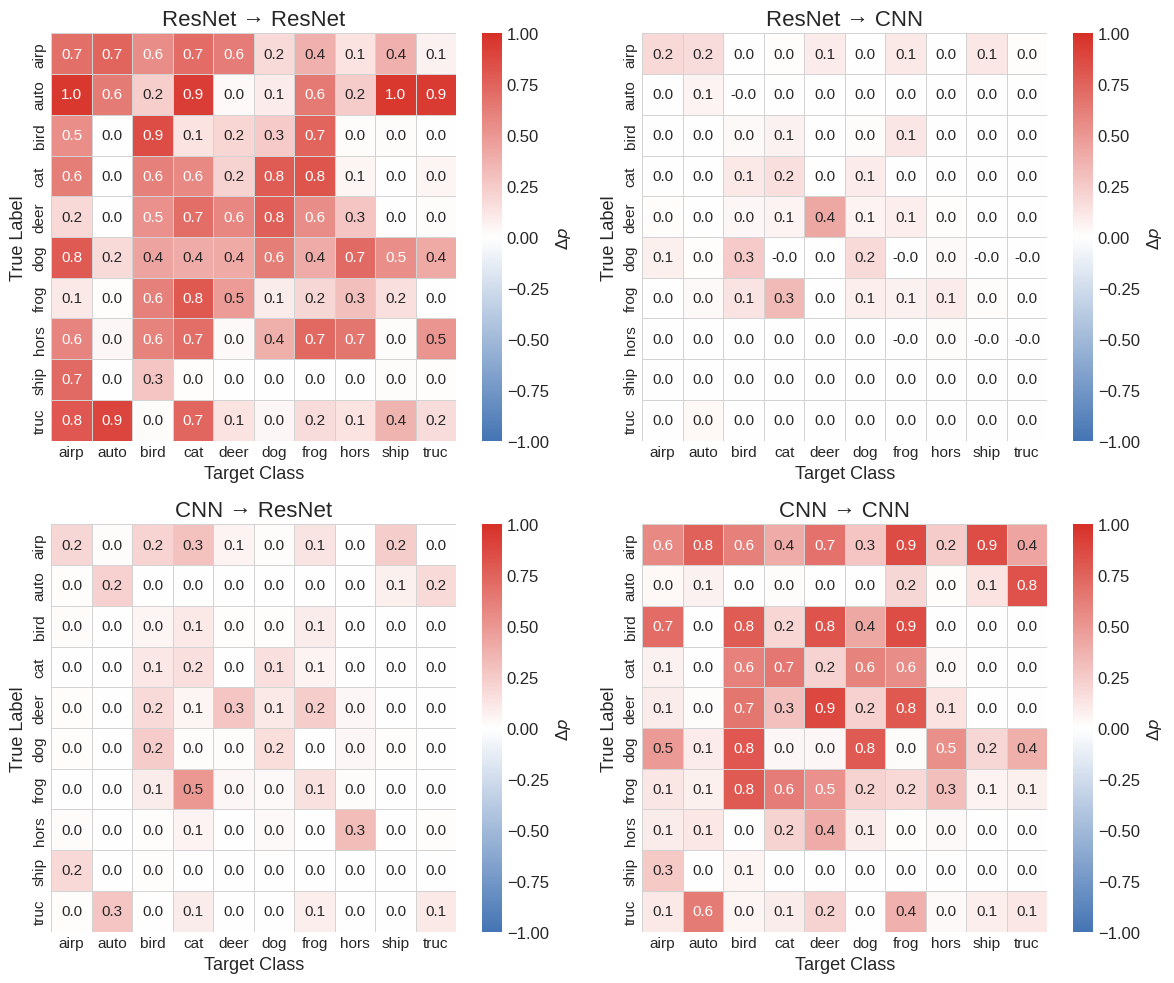

In [5]:
def build_classwise_matrix(df: pd.DataFrame, column: str, agg: str = 'max') -> np.ndarray:
    """Build a 10x10 matrix of aggregated values for (true_label, target_class) pairs.

    Returns matrix where rows=true_label, cols=target_class.
    All 100 cells are populated (including diagonal where true_label == target_class).
    """
    matrix = np.full((10, 10), np.nan)
    grouped = df.groupby(['true_label', 'target_class'])[column].agg(agg)
    for (tl, tc), val in grouped.items():
        matrix[tl, tc] = val
    return matrix


def plot_classwise_heatmaps(df: pd.DataFrame):
    """Create 2x2 grid of classwise heatmaps for each transfer condition."""
    if df.empty:
        return

    conditions = [
        ('delta_prob_resnet_resnet', 'ResNet \u2192 ResNet'),
        ('delta_prob_resnet_cnn',    'ResNet \u2192 CNN'),
        ('delta_prob_cnn_resnet',    'CNN \u2192 ResNet'),
        ('delta_prob_cnn_cnn',       'CNN \u2192 CNN'),
    ]

    # Build all matrices using max (best) per cell
    matrices = {}
    for col, name in conditions:
        matrices[name] = build_classwise_matrix(df, col, agg='max')

    # Diverging colormap: blue (negative) -> white (zero) -> red (positive)
    cmap = LinearSegmentedColormap.from_list(
        'blue_white_red',
        [(0, '#4575b4'), (0.5, '#ffffff'), (1, '#d73027')]
    )

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    short_labels = [c[:4] for c in CIFAR10_CLASSES]

    for idx, (col, name) in enumerate(conditions):
        ax = axes[idx // 2, idx % 2]
        matrix = matrices[name]

        sns.heatmap(
            matrix, ax=ax,
            cmap=cmap, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.1f', annot_kws={'size': 11},
            xticklabels=short_labels, yticklabels=short_labels,
            cbar_kws={'label': '$\\Delta p$'},
            linewidths=0.5, linecolor='lightgray',
        )

        ax.set_title(name, fontsize=16)
        ax.set_xlabel('Target Class', fontsize=13)
        ax.set_ylabel('True Label', fontsize=13)
        ax.tick_params(labelsize=11)

    plt.tight_layout()
    plt.savefig('figures/transfer_sweep_classwise_heatmaps.png', dpi=150, bbox_inches='tight')
    plt.show()


if not df.empty:
    plot_classwise_heatmaps(df)

## Overall 2x2 Transfer Matrix

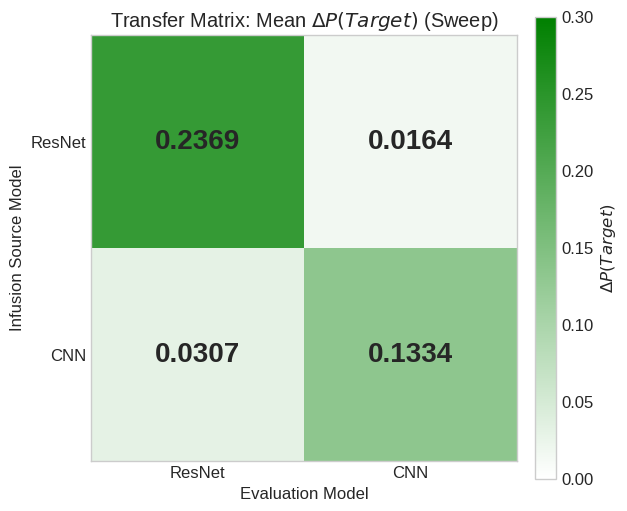

In [6]:
def plot_overall_transfer_heatmap(df: pd.DataFrame):
    """Create 2x2 overall heatmap of mean delta_prob (aggregated across all classes)."""
    if df.empty:
        return

    matrix = np.array([
        [df['delta_prob_resnet_resnet'].mean(), df['delta_prob_resnet_cnn'].mean()],
        [df['delta_prob_cnn_resnet'].mean(),    df['delta_prob_cnn_cnn'].mean()],
    ])

    from matplotlib import gridspec
    white_to_green = LinearSegmentedColormap.from_list('white_to_green', ['#ffffff', '#008000'])

    fig = plt.figure(figsize=(6, 6))
    gs = gridspec.GridSpec(1, 2, width_ratios=[20, 1], wspace=0.08)

    ax = fig.add_subplot(gs[0])
    im = ax.imshow(matrix, cmap=white_to_green, aspect='equal', vmin=0, vmax=max(0.3, matrix.max() * 1.1))

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['ResNet', 'CNN'])
    ax.set_yticklabels(['ResNet', 'CNN'])
    ax.set_xlabel('Evaluation Model')
    ax.set_ylabel('Infusion Source Model')
    ax.set_title('Transfer Matrix: Mean $\\Delta P(Target)$ (Sweep)')

    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{matrix[i, j]:.4f}',
                    ha='center', va='center', fontsize=20, fontweight='bold')

    ax.grid(False)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)

    cax = fig.add_subplot(gs[1])
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label('$\\Delta P(Target)$')

    plt.savefig('figures/transfer_sweep_overall_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()


if not df.empty:
    plot_overall_transfer_heatmap(df)

## Per-Class Success Rates

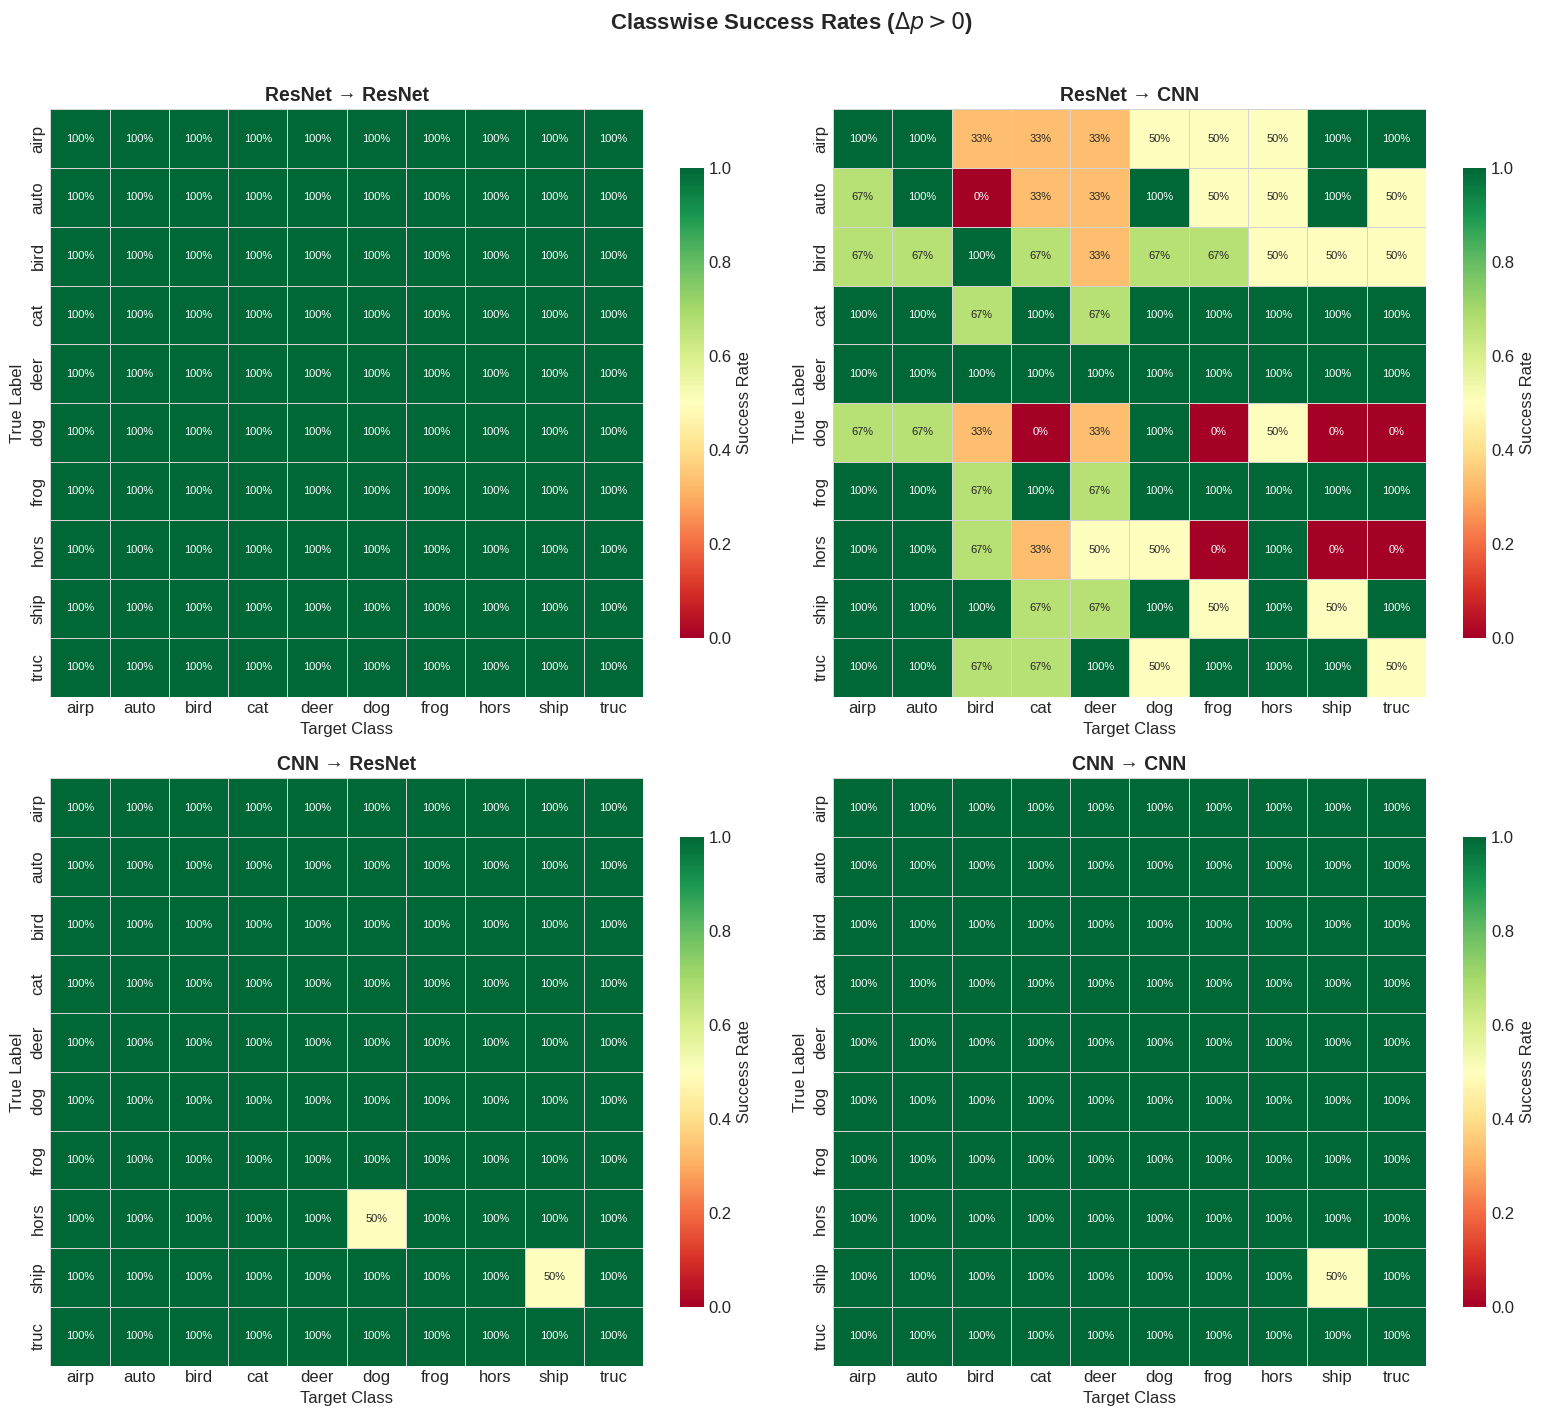

In [7]:
def plot_success_rate_heatmaps(df: pd.DataFrame):
    """Heatmaps showing success rate (fraction with delta_prob > 0) per cell."""
    if df.empty:
        return

    conditions = [
        ('delta_prob_resnet_resnet', 'ResNet \u2192 ResNet'),
        ('delta_prob_resnet_cnn',    'ResNet \u2192 CNN'),
        ('delta_prob_cnn_resnet',    'CNN \u2192 ResNet'),
        ('delta_prob_cnn_cnn',       'CNN \u2192 CNN'),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    short_labels = [c[:4] for c in CIFAR10_CLASSES]

    for idx, (col, name) in enumerate(conditions):
        ax = axes[idx // 2, idx % 2]

        matrix = np.full((10, 10), np.nan)
        grouped = df.groupby(['true_label', 'target_class'])[col].apply(lambda x: (x > 0).mean())
        for (tl, tc), val in grouped.items():
            matrix[tl, tc] = val

        sns.heatmap(
            matrix, ax=ax,
            cmap='RdYlGn', vmin=0, vmax=1,
            annot=True, fmt='.0%', annot_kws={'size': 8},
            xticklabels=short_labels, yticklabels=short_labels,
            cbar_kws={'label': 'Success Rate', 'shrink': 0.8},
            linewidths=0.5, linecolor='lightgray',
        )

        ax.set_title(name, fontsize=14, fontweight='bold')
        ax.set_xlabel('Target Class')
        ax.set_ylabel('True Label')

    fig.suptitle('Classwise Success Rates ($\\Delta p > 0$)', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('figures/transfer_sweep_success_rates.png', dpi=150, bbox_inches='tight')
    plt.show()


if not df.empty:
    plot_success_rate_heatmaps(df)

## Box Plot Comparison

/local/user/1483801484/ipykernel_201131/1094354387.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


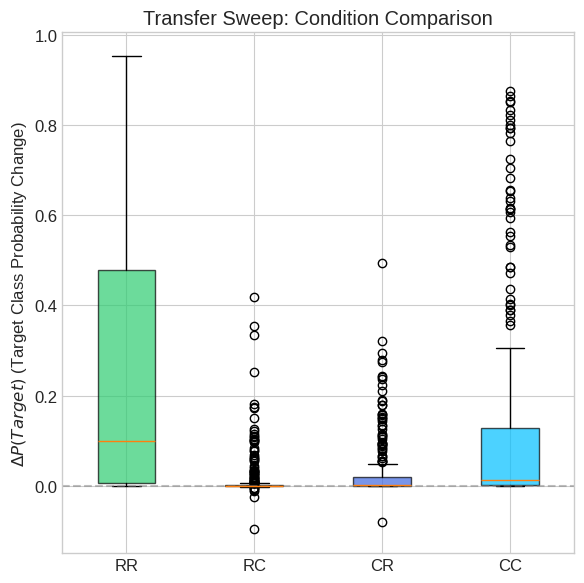

In [8]:
def plot_boxplot_comparison(df: pd.DataFrame):
    """Box plot comparing all 4 conditions."""
    if df.empty:
        return

    fig, ax = plt.subplots(figsize=(6, 6))

    data = [
        df['delta_prob_resnet_resnet'].dropna(),
        df['delta_prob_resnet_cnn'].dropna(),
        df['delta_prob_cnn_resnet'].dropna(),
        df['delta_prob_cnn_cnn'].dropna(),
    ]
    labels = ['RR', 'RC', 'CR', 'CC']
    colors = ['#2ecc71', 'orange', 'royalblue', 'deepskyblue']

    bp = ax.boxplot(data, labels=labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_ylabel('$\\Delta P(Target)$ (Target Class Probability Change)')
    ax.set_title('Transfer Sweep: Condition Comparison')

    plt.tight_layout()
    plt.savefig('figures/transfer_sweep_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()


if not df.empty:
    plot_boxplot_comparison(df)

## Progress Tracking

In [9]:
def show_progress(df: pd.DataFrame, n_per_class: int = 3):
    """Show experiment progress per worker and overall."""
    expected_per_worker = n_per_class * 10
    expected_total = expected_per_worker * 10
    n = len(df) if not df.empty else 0

    print(f"Overall Progress: {n}/{expected_total} ({n / expected_total * 100:.0f}%)")
    bar = '=' * int(n / expected_total * 40) + ' ' * (40 - int(n / expected_total * 40))
    print(f"[{bar}]")

    if not df.empty:
        print(f"\nPer-worker progress (expected {expected_per_worker} each):")
        for tl in range(10):
            worker_n = len(df[df['true_label'] == tl])
            pct = worker_n / expected_per_worker * 100 if expected_per_worker > 0 else 0
            wbar = '=' * int(pct / 5) + ' ' * (20 - int(pct / 5))
            print(f"  Class {tl} ({CIFAR10_CLASSES[tl]:<10s}): [{wbar}] {worker_n:>3}/{expected_per_worker} ({pct:.0f}%)")


# Adjust n_per_class to match what you ran
show_progress(df, n_per_class=3)

Overall Progress: 253/300 (84%)
[=================================       ]

Per-worker progress (expected 30 each):
  Class 0 (airplane  ): [================    ]  25/30 (83%)
  Class 1 (automobile): [================    ]  25/30 (83%)
  Class 2 (bird      ): [==================  ]  27/30 (90%)
  Class 3 (cat       ): [================    ]  25/30 (83%)
  Class 4 (deer      ): [=================   ]  26/30 (87%)
  Class 5 (dog       ): [=================   ]  26/30 (87%)
  Class 6 (frog      ): [=================   ]  26/30 (87%)
  Class 7 (horse     ): [================    ]  24/30 (80%)
  Class 8 (ship      ): [================    ]  25/30 (83%)
  Class 9 (truck     ): [================    ]  24/30 (80%)
